### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 24/24 [01:09<00:00,  2.89s/it]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851149,2026-03-13 17:59:35,71009.000000,71009.000000,70992.601562,70999.203125,4.246,0.021,0.011,0.010,0.047619,...,2.866,0.212,0.580,0.002,0.018,0.002,0.002,0.631,0.002,4.023
851150,2026-03-13 17:59:40,70993.203125,71000.203125,70991.101562,70997.296875,3.054,0.460,0.214,0.246,-0.069565,...,0.002,2.593,2.154,4.041,0.002,0.003,1.438,0.034,0.027,0.140
851151,2026-03-13 17:59:45,70995.000000,70996.296875,70990.101562,70996.296875,1.782,0.000,0.000,0.000,0.000000,...,0.006,0.140,0.732,0.027,0.002,0.002,0.018,0.022,0.002,0.735
851152,2026-03-13 17:59:50,70983.500000,70993.500000,70983.398438,70985.601562,4.335,0.554,0.003,0.551,-0.989170,...,0.105,0.004,0.009,0.002,0.003,0.002,0.009,0.009,0.002,0.038


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 851153/851153 [00:07<00:00, 113183.37it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,1.591322e-04,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.141357,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,2.141049e-04,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.134234,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,2.752305e-04,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.134234,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,4.429674e-04,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.130717,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,9.560574e-04,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.137894,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851149,15.120052,0.727109,28.335883,26.318453,1.046618e-07,15.120031,0.218055,1.654551,0.780759,30.181990,...,0.987970,2.747221,2.771074,0.658527,0.662684,70992.601562,71009.000000,70999.203125,-0.000050,0.000128
851150,15.190104,0.221625,27.694739,25.191401,1.720900e-07,15.190083,0.824578,-4.474389,-1.898496,-68.310877,...,0.981137,0.103314,-5.772870,-0.788561,-0.789059,70991.101562,71000.203125,70997.296875,-0.000058,0.000087
851151,15.283594,0.149906,27.011424,23.953744,3.845789e-07,15.283572,0.876000,-2.552467,-1.147343,-46.818383,...,0.978335,0.877376,-3.972621,-0.672821,-0.680746,70990.101562,70996.296875,70996.296875,-0.000111,0.000142
851152,15.603516,3.122555,26.540992,23.092161,2.010351e-06,15.603494,0.355406,-0.100549,-0.012960,-29.135864,...,0.990605,0.507533,-2.032838,-0.031374,0.004980,70983.398438,70993.500000,70985.601562,0.000280,0.000480


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=3,
)

Обучение модели...
[0]	validation_0-rmse:0.00020
[50]	validation_0-rmse:0.00020
[100]	validation_0-rmse:0.00019
[150]	validation_0-rmse:0.00019
[200]	validation_0-rmse:0.00019
[250]	validation_0-rmse:0.00019
[300]	validation_0-rmse:0.00019
[350]	validation_0-rmse:0.00019
[400]	validation_0-rmse:0.00019
[450]	validation_0-rmse:0.00018
[500]	validation_0-rmse:0.00018
[550]	validation_0-rmse:0.00018
[600]	validation_0-rmse:0.00018
[650]	validation_0-rmse:0.00018
[700]	validation_0-rmse:0.00018
[750]	validation_0-rmse:0.00018
[800]	validation_0-rmse:0.00018
[850]	validation_0-rmse:0.00018
[900]	validation_0-rmse:0.00018
[950]	validation_0-rmse:0.00018
[1000]	validation_0-rmse:0.00018
[1050]	validation_0-rmse:0.00018
[1100]	validation_0-rmse:0.00018
[1150]	validation_0-rmse:0.00018
[1200]	validation_0-rmse:0.00018
[1250]	validation_0-rmse:0.00018
[1300]	validation_0-rmse:0.00018
[1350]	validation_0-rmse:0.00018
[1400]	validation_0-rmse:0.00018
[1450]	validation_0-rmse:0.00018
[1500]	validat

MAE                      : 0.000118
RMSE                     : 0.000183
R²                       : 0.204669
MAE / mean|Δ|            : 0.864700
RMSE / RMSE_base         : 0.891792
mean|Δ| (target)         : 0.000137

------------------------------------------------------------
Directional Accuracy     : 0.619574
Target Pos Ratio         : 0.484946
Profit Factor            : 1.646194
Avg Gain (correct)       : -0.000006
Avg Loss (incorrect)     : 0.000006

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6174, 0.6217)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000117, 0.00103]    0.000220         0.901662    -0.000005      17023
(6.67e-05, 0.000117]    0.000087         0.756903    -0.000003      17022
(4.58e-05, 6.67e-05]    0.000055         0.685191    -0.000002      17023


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


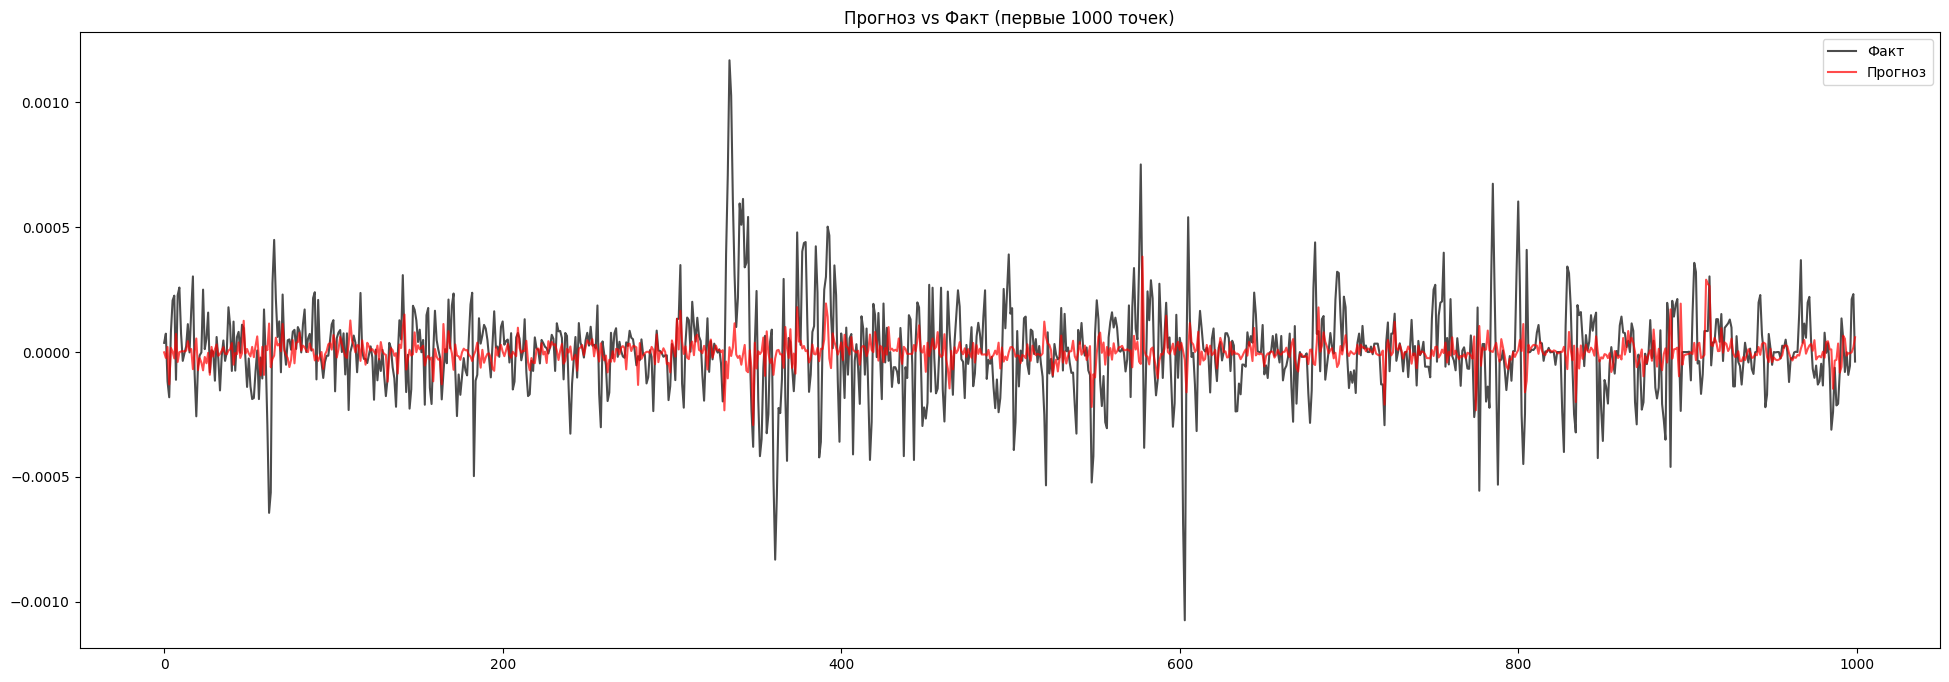

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=6,
)

Обучение модели...
[0]	validation_0-rmse:0.00021
[50]	validation_0-rmse:0.00019
[100]	validation_0-rmse:0.00017
[150]	validation_0-rmse:0.00017
[200]	validation_0-rmse:0.00017
[250]	validation_0-rmse:0.00017
[300]	validation_0-rmse:0.00017
[350]	validation_0-rmse:0.00017
[400]	validation_0-rmse:0.00017
[450]	validation_0-rmse:0.00017
[500]	validation_0-rmse:0.00017
[550]	validation_0-rmse:0.00017
[600]	validation_0-rmse:0.00017
[650]	validation_0-rmse:0.00017
[700]	validation_0-rmse:0.00017
[750]	validation_0-rmse:0.00017
[800]	validation_0-rmse:0.00017
[850]	validation_0-rmse:0.00017
[900]	validation_0-rmse:0.00017
[922]	validation_0-rmse:0.00017
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000112
RMSE                     : 0.000167
R²                       : 0.391380
MAE / mean|Δ|            : 0.540847
RMSE / RMSE_base         : 0.560377
mean|Δ| (target)         : 0.000208

------------------------------------------------------------
Directional Accuracy     : 0.929487
Target Pos Ratio         : 0.929487
Profit Factor            : 35360983148.125015
Avg Gain (correct)       : 0.000223
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.9282, 0.9307)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000388, 0.00254]    0.000520         0.999941     0.000512      17023
(0.000292, 0.000388]    0.000334         0.998943     0.000330      17022
(0.000238, 0.000292]    0.000264         0.995888     0.000263    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


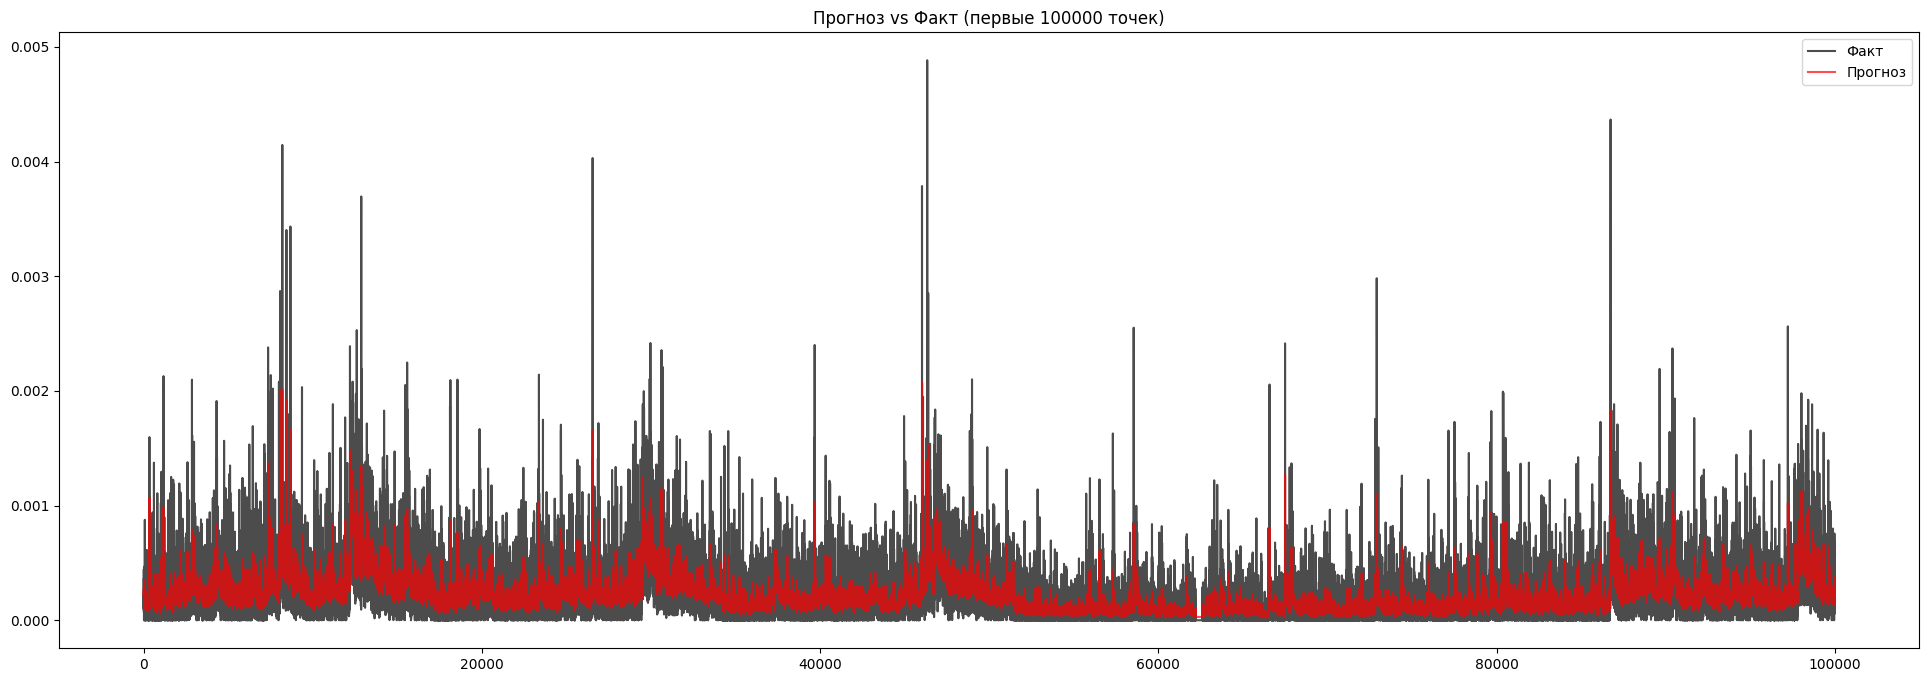

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)